# Essential & Vital Workers — Workflow Notebook

This notebook is the **guided walkthrough** for the essential-worker pipeline.

Use this notebook to:

1. Reproduce every CSV under `results/` from `data/` inputs.
2. See each pipeline stage step-by-step (not only the one-shot `run_pipeline`).
3. Compare the four **indoor-fraction** methods and understand when to use each.
4. Inspect overlap calibration, on-site housing adjustments, and ILO validation.

**Downstream:** `scripts/scale_up_processing.ipynb` and
`scripts/visualization/EssentialWorkers_Choropleth_Visualiser.ipynb`
read `results/EssentialWorkersByCountry.csv`.

### Inputs (`data/`)

| File | Role |
| --- | --- |
| `ISCO-08 OpinionPollCensus.xlsx` | In-house vital poll (0/1) at ISCO L4 |
| `Indoors_Environmentally_Controlled_data.csv` | O*NET indoor context % (controlled) |
| `Indoors_Not_Environmentally_Controlled.csv` | O*NET indoor context % (not controlled) |
| `ISCO_SOC_Crosswalk.csv` | SOC → ISCO-08 mapping |
| `ILO_ISCO_08_GLB.csv` | ILO employment by country × ISCO L2 |
| `LFData_WB_plus.xlsx` | World Bank labour force 2024 |
| `ILO_country_essential_workers_pct.xlsx` | ILO WESO 2023 published %essential |
| `job_exposure_matrix.xls` | JEM Location for `jem_partial` / `jem_binary` (required for those methods) |
| `../scale_up/settings.csv` | `IndoorContextMethod` — default pipeline indoor rule (`jem_binary`) |

### Outputs (`results/`)

| File | Contents |
| --- | --- |
| `EssentialWorkersByCountry.csv` | Per-country counts & percentages |
| `EssentialWorkersByRegion.csv` | UN regional aggregates |
| `Essential_Workers_Validation.csv` | Model vs calibrated vs ILO %essential |
| `Group_Overlap_Calibration.csv` | Per-country × group overlap adjustments |
| `Onsite_Housing_Worker_Requirements.csv` | Housing-relevant totals (excl. ISCO 61+63) |
| `Indoor_Context_Sensitivity.csv` | Global totals under each indoor method (optional) |


## Methodology Overview

> ILO (2023). **World Employment and Social Outlook 2023: The value of essential work.**
> International Labour Organization.
> [WCMS_871016](https://www.ilo.org/sites/default/files/wcmsp5/groups/public/@dgreports/@dcomm/@publ/documents/publication/wcms_871016.pdf)

The ILO classifies a worker as a *key worker* (essential worker) if **both** of these are true:

1. They are in a key **occupation** (ISCO-08 code listed in Table A2 of the report).
2. They are in a key **industry** (ISIC Rev.4 code listed in Table A1 of the report).

So `essential = occupation AND industry`, not just one or the other. The ILO computes its per-country shares from worker-level microdata in which every respondent has both an ISCO code and an ISIC code, so the intersection is exact.

### Our calculations

**We do not have access to ILO worker-level ISCO x ISIC microdata.** The only country-level breakdown we have is ILO employment per ISCO-08 L2 code (`ILO_ISCO_08_GLB.csv`). To approximate the intersection we use Figure A1 from the linked report above as **global priors** (`GROUP_OVERLAP[g]`) and then **calibrate** them per country.

**1. Global priors.** For each occupational group *g*, `GROUP_OVERLAP[g]` is the globally aggregated fraction of workers in group *g* that are also in a key ISIC industry (ILO Figure A1). Armed Forces uses 0.40 (Blueprint; ILO excludes uniformed services from headline figures).

The global average group overlap factors:

| Group | Overlap | Source |
| --- | ---: | --- |
| Food | 0.895 | ILO Figure A1 |
| Health | 0.819 | ILO Figure A1 |
| Retail | 0.876 | ILO Figure A1 |
| Security | 0.846 | ILO Figure A1 |
| Transport | 0.869 | ILO Figure A1 |
| Manual | 0.335 | ILO Figure A1 |
| Cleaning | 0.485 | ILO Figure A1 |
| Tech | 0.320 | ILO Figure A1 |
| Armed Forces | **0.40** | Blueprint Biosecurity's "A theory of pandemic-proof PPE" https://blueprintbiosecurity.org/u/2024/05/BB_Next-Gen-Report_PRF9-WEB-1.pdf?utm_source=bluedot-impact (as the ILO excludes armed forces from its global figures) |

**2. Per-country calibration.** For each country with ILO ISCO employment and a published WESO %essential, one scalar `x ∈ [0, 1]` moves all eight calibratable groups together: toward 1.0 when the model under-shoots ILO, toward 0 when it over-shoots. Armed Forces overlap stays fixed at 0.40. This is implemented in `essential_workers.calibrate_group_overlaps` and logged in `results/Group_Overlap_Calibration.csv`. For countries without data (e.g. China), calibrated overlaps are the mean of `SIMILAR_ISO3` neighbours' calibrated values.

**3. Applying overlaps to calculate vital workers** using the calibrated overlaps obtained from step 2, we apply them to a smaller set of ISCO-08 job categories. These were defined by team members each flagging ISCO-08 job categories as vital or not vital at the 4-digit code level (specific job categories). As the ILO employment data is at the 2-digit level (broader job categories), we take the mean of the 4-digit codes within each 2-digit category.


**4. Estimate indoor workers** We multiply the essential worker weights and vital worker weights by `indoors_context` (0–1), which is the fraction of that job category spent inside
and therefore benefitting from in-room air filtration. We derive this from O*NET or JEM datasets on time spent working indoors by job category. The active rule is set by `IndoorContextMethod` in `data/scale_up/settings.csv` (default: `jem_binary`).


## 0. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print  # running as plain script

REPO = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

import essential_workers as ew

DATA = REPO / 'data/essential_workers'
RESULTS = REPO / 'results/essential_workers'
RESULTS.mkdir(exist_ok=True)

JEM_PATH = DATA / 'job_exposure_matrix.xls'
HAS_JEM = JEM_PATH.exists()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

print(f'Repo:    {REPO}')
print(f'Data:    {DATA}  (exists={DATA.is_dir()})')
print(f'Results: {RESULTS}')
print(f'JEM file: {JEM_PATH.name} present={HAS_JEM}')
print(f'IndoorContextMethod (settings): {ew.load_indoor_context_method()}')


Repo:    /Users/james/Documents/Github/InRoomAirFilterScaleUp
Data:    /Users/james/Documents/Github/InRoomAirFilterScaleUp/data/essential_workers  (exists=True)
Results: /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/essential_workers
JEM file: job_exposure_matrix.xls present=True
IndoorContextMethod (settings): jem_binary


## 1. Quick-start — full pipeline

One call mirrors `python src/essential_workers.py` and writes all standard CSVs.
The indoor fraction comes from `IndoorContextMethod` in `data/scale_up/settings.csv`
(default: `jem_binary`). Override with `indoor_context_method=...` if needed.

Manuscript numbers are printed in **Key results** (section 10).
Set `write_indoor_sensitivity=True` to also save `Indoor_Context_Sensitivity.csv`.


In [2]:
outputs = ew.run_pipeline(
    data_dir=DATA,
    results_dir=RESULTS,
    write=True,
    write_indoor_sensitivity=True,
)
lf = outputs.labour_force_df
method = ew.load_indoor_context_method()
print(f'Pipeline complete — {len(lf)} countries (IndoorContextMethod={method}).')
print('See **Key results** (section 10) for manuscript numbers.')


Pipeline complete — 217 countries (IndoorContextMethod=jem_binary).
See **Key results** (section 10) for manuscript numbers.


### Occupational-group composition

Worker-weighted breakdown of who makes up the essential / vital workforces
(Food, Health, Retail, …). Global / region / country CSVs are written by
`run_pipeline`; the figure is from `plot_group_composition.py`.


In [3]:
group_comp = ew.summarize_group_composition(outputs.group_df)
display(
    group_comp.assign(
        **{
            c: (group_comp[c] * 100).round(1)
            for c in ew.GROUP_COMPOSITION_SHARE_COLS
        }
    )[["occupational_group", *ew.GROUP_COMPOSITION_SHARE_COLS]]
)
print(
    "\nAlso available: "
    "summarize_group_composition(..., by='Region'|'Country') "
    "→ EssentialWorkersByGroupComposition_*.csv"
)


,occupational_group,% of Essential Workers,% of Vital Workers,% of Indoor Essential Workers,% of Indoor Vital Workers
0,Food,45.9,69.0,5.2,7.1
1,Health,6.0,5.1,12.5,17.4
2,Retail,17.2,2.0,27.0,5.2
3,Security,2.3,2.9,5.0,10.0
4,Transport,7.6,9.5,13.2,27.1
5,Manual,12.8,9.3,22.1,26.3
6,Cleaning,3.9,0.5,6.4,1.1
7,Tech,3.9,1.4,7.8,4.9
8,ArmedForces,0.4,0.2,0.8,0.8



Also available: summarize_group_composition(..., by='Region'|'Country') → EssentialWorkersByGroupComposition_*.csv


## 2. Preprocessing — load inputs & build ISCO weights

This section mirrors the **first half** of `run_pipeline`: read files, build the L2
weight table (poll + indoor context + ILO essential flag + group overlaps).

### 2.1 Load raw inputs


In [4]:
poll_df = pd.read_excel(DATA / 'ISCO-08 OpinionPollCensus.xlsx', engine='openpyxl')
onet_env_df = pd.read_csv(DATA / 'Indoors_Environmentally_Controlled_data.csv')
onet_not_df = pd.read_csv(DATA / 'Indoors_Not_Environmentally_Controlled.csv')
crosswalk_df = pd.read_csv(DATA / 'ISCO_SOC_Crosswalk.csv')
ilo_emp_df = pd.read_csv(DATA / 'ILO_ISCO_08_GLB.csv')
lf_raw = pd.read_excel(DATA / 'LFData_WB_plus.xlsx', usecols=[0, 1, 3])
ilo_pct_df = ew.load_ilo_published_pct(DATA / 'ILO_country_essential_workers_pct.xlsx')

for name, df in [
    ('poll', poll_df), ('ONET env', onet_env_df), ('ONET not', onet_not_df),
    ('crosswalk', crosswalk_df), ('ILO emp', ilo_emp_df), ('LF', lf_raw), ('ILO pct', ilo_pct_df),
]:
    print(f'{name:12s} {df.shape}')


poll         (436, 39)
ONET env     (879, 4)
ONET not     (894, 4)
crosswalk    (1125, 6)
ILO emp      (38734, 11)
LF           (217, 3)
ILO pct      (90, 3)


### 2.2 Weight template (before group overlaps)

`_build_isco_lvl2_template` attaches `indoors_context` at L4, averages to L2, sets
`Essential Weight ILO`, maps `Group`, and applies poll/ILO teleworkable rules.
Default indoor method matches `run_pipeline` — read from `IndoorContextMethod` in
`data/scale_up/settings.csv` (currently `jem_binary`).


In [5]:
indoor_method = ew.load_indoor_context_method()
jem_methods = ('jem_partial', 'jem_binary')
weights_template = ew._build_isco_lvl2_template(
    poll_df,
    crosswalk_df,
    onet_controlled_df=onet_env_df,
    onet_not_controlled_df=onet_not_df,
    indoor_context_method=indoor_method,
    jem_path=JEM_PATH if indoor_method in jem_methods else None,
)
print(f'Building weight template with indoor_context_method={indoor_method!r}')
weights = ew.apply_group_overlaps(weights_template, ew.GROUP_OVERLAP)

cols = [
    'Vital Weight POLL', ew.INDOORS_CONTEXT_COLUMN, 'Essential Weight ILO',
    'Group', 'Group Overlap',
    'ISCO_08_PollWeights', 'ISCO_08_ILOWeights',
    'ISCO_08_PollWeights_Total', 'ISCO_08_ILOWeights_Total',
]
display(weights[cols].head(12))

print('Subsistence farmers (63) indoor context:', weights.at['63', ew.INDOORS_CONTEXT_COLUMN])
print('NON_ILO poll-zero codes:', ew.NON_ILO_POLL_CODES)


Building weight template with indoor_context_method='jem_binary'


,Vital Weight POLL,indoors_context,Essential Weight ILO,Group,Group Overlap,ISCO_08_PollWeights,ISCO_08_ILOWeights,ISCO_08_PollWeights_Total,ISCO_08_ILOWeights_Total
ISCO-08,,,,,,,,,
01,0.400000,1.000000,1,ArmedForces,0.400,0.1600,0.400,0.1600,0.400
02,0.400000,1.000000,1,ArmedForces,0.400,0.1600,0.400,0.1600,0.400
03,0.400000,1.000000,1,ArmedForces,0.400,0.1600,0.400,0.1600,0.400
11,0.000000,0.600000,0,NaN,0.000,0.0000,0.000,0.0000,0.000
12,0.000000,0.000000,0,NaN,0.000,0.0000,0.000,0.0000,0.000
13,0.000000,0.928571,0,NaN,0.000,0.0000,0.000,0.0000,0.000
14,0.000000,1.000000,0,NaN,0.000,0.0000,0.000,0.0000,0.000
21,0.000000,0.583333,0,NaN,0.000,0.0000,0.000,0.0000,0.000
22,0.533333,1.000000,1,Health,0.819,0.4368,0.819,0.4368,0.819


Subsistence farmers (63) indoor context: 0.0
NON_ILO poll-zero codes: ['13', '21', '33', '35']


### 2.3 Per-country ILO employment by ISCO L2

`build_employment_by_isco` builds one employment snapshot per country:

- **Sex:** only `sex.label == "Total"` (Male/Female rows are dropped).
- **Year:** one survey year for all ISCO codes in that country — the latest year with NEC (“Not elsewhere classified”) ≤ 10% of total employment; if every year is above 10%, the year with the **lowest** NEC share (ties → more recent year).
- **Headcount:** `obs_value` (thousands) × 1000; ISCO L2 keys are stripped/normalised (`22`, `Tot`, `Not`).

In `compute_worker_dicts`, NEC employment is added to essential/vital numerators at each country’s **employment-weighted average** essential/vital weight over coded occupations (excluding `Tot` and `Not`). The official `Tot` row remains the denominator for % columns.


In [6]:
employment_by_iso = ew.build_employment_by_isco(ilo_emp_df)
sample = next(iter(employment_by_iso))
print(f'Countries with ILO breakdown: {len(employment_by_iso)}')
display(pd.Series(employment_by_iso[sample]).head(12))


Countries with ILO breakdown: 149


Tot    7679474.0
02      209728.0
11        7876.0
12       89945.0
13       23102.0
14       10688.0
21       22794.0
22       63733.0
23      236394.0
24        9108.0
26       58692.0
32        9930.0
dtype: float64

## 3. Indoor-fraction methods — comparison

The **indoor fraction** (`indoors_context`, 0–1) scales indoor vital/essential counts.
It does **not** change total vital/essential (the `_Total` weight columns omit it).

The main pipeline reads `IndoorContextMethod` from `data/scale_up/settings.csv`
(current default: **`jem_binary`**). Section 3 runs all four methods side-by-side.

| Method | Source | Rule | When to use |
| --- | --- | --- | --- |
| **`jem_binary`** (default) | `job_exposure_matrix.xls` | JEM Location 0/1 → 0%; 2/3 → 100% | Main results; binary indoor/outdoor from JEM |
| **`jem_partial`** | Same JEM file | 0/1 → 0%; 2 → 50%; 3 → 100% | Sensitivity; treats Location 2 as half-indoor |
| **`onet_max`** | Both O*NET CSVs | Per SOC: `max(env, not_env)` context % ÷ 100 | O*NET-based; smooth 0–1 |
| **`onet_banded`** | Same O*NET | ≥75% → 1.0; 50–75% → 0.5; else 0 | O*NET step-function sensitivity |

All four methods use the same poll, ILO essential flags, and overlap calibration.


### 3.1 L2 `indoors_context` under each method


In [7]:
def weights_for_method(method: ew.IndoorContextMethod) -> pd.DataFrame:
    jem_methods = ('jem_partial', 'jem_binary')
    return ew.build_isco_lvl2_weights(
        poll_df, crosswalk_df,
        onet_controlled_df=onet_env_df,
        onet_not_controlled_df=onet_not_df,
        indoor_context_method=method,
        jem_path=JEM_PATH if method in jem_methods else None,
    )

methods: list[ew.IndoorContextMethod] = list(ew.INDOOR_CONTEXT_METHODS)
if not HAS_JEM:
    methods = [m for m in methods if not m.startswith('jem_')]
    print('Skipping jem_partial and jem_binary — job_exposure_matrix.xls not in data/')

indoor_compare = pd.DataFrame({
    m: weights_for_method(m)[ew.INDOORS_CONTEXT_COLUMN] for m in methods
})
indoor_compare['spread'] = indoor_compare.max(axis=1) - indoor_compare.min(axis=1)
print('L2 codes where methods disagree most (top 10 by spread):')
display(indoor_compare.sort_values('spread', ascending=False).head(10))
print('\nSummary stats of indoors_context by method:')
display(indoor_compare[methods].describe().T)


L2 codes where methods disagree most (top 10 by spread):


,onet_max,onet_banded,jem_partial,jem_binary,spread
ISCO-08,,,,,
12,0.866136,0.964286,0.000000,0.000000,0.964286
25,0.849585,0.918985,0.000000,0.000000,0.918985
24,0.828455,0.912121,0.000000,0.000000,0.912121
43,0.773333,0.750000,0.083333,0.166667,0.690000
44,0.877500,0.900000,0.214286,0.428571,0.685714
35,0.890000,1.000000,0.333333,0.333333,0.666667
21,0.854463,0.946037,0.333333,0.583333,0.612704
83,0.472576,0.207071,0.636364,0.818182,0.611111
33,0.831627,0.886586,0.291667,0.458333,0.594919



Summary stats of indoors_context by method:


,count,mean,std,min,25%,50%,75%,max
onet_max,43.0,0.756783,0.180103,0.0,0.711640,0.801136,0.854037,1.0
onet_banded,43.0,0.751107,0.261960,0.0,0.684544,0.816667,0.938378,1.0
jem_partial,43.0,0.583184,0.371500,0.0,0.302083,0.666667,0.905882,1.0
jem_binary,43.0,0.659189,0.373113,0.0,0.443452,0.818182,1.000000,1.0


### 3.2 O*NET SOC → ISCO example (how `onet_max` vs `onet_banded` differ)

At SOC level we take the max of both context columns, then map through the crosswalk.
JEM methods (`jem_partial`, `jem_binary`) use the Location scale instead — see
`preprocessing.location_to_indoor_fraction`.


In [8]:
soc_merged = ew._merge_onet_max_context(onet_env_df, onet_not_df)
sample_soc = soc_merged.head(5).copy()
sample_soc['onet_max_frac'] = sample_soc['context_pct'].apply(
    lambda p: ew._pct_to_indoor_fraction(p, 'onet_max')
)
sample_soc['onet_banded_frac'] = sample_soc['context_pct'].apply(
    lambda p: ew._pct_to_indoor_fraction(p, 'onet_banded')
)
display(sample_soc)

print('\nJEM Location bucket examples (mean Location → nearest bucket):')
for loc in [0.2, 1.0, 2.1, 2.9]:
    partial = ew._location_to_indoor_fraction(loc, partial=True)
    binary = ew._location_to_indoor_fraction(loc, partial=False)
    print(f'  Location {loc}: jem_partial={partial}, jem_binary={binary}')


,Code,context_pct,onet_max_frac,onet_banded_frac
0,11-1011,96.0,0.96,1.0
1,11-1011,96.0,0.96,1.0
2,11-1011,94.0,0.94,1.0
3,11-1011,94.0,0.94,1.0
4,11-1021,85.0,0.85,1.0



JEM Location bucket examples (mean Location → nearest bucket):
  Location 0.2: jem_partial=0.0, jem_binary=0.0
  Location 1.0: jem_partial=0.0, jem_binary=0.0
  Location 2.1: jem_partial=0.5, jem_binary=1.0
  Location 2.9: jem_partial=1.0, jem_binary=1.0


### 3.3 Global worker totals — side-by-side (all four methods)


In [9]:
sensitivity = ew.compare_indoor_context_methods(DATA)
pivot = sensitivity.pivot(
    index='Category', columns='indoor_context_method', values='% of Labour Force'
)
display(pivot.round(2))

if (RESULTS / 'Indoor_Context_Sensitivity.csv').exists():
    print(f'Also on disk: {RESULTS / "Indoor_Context_Sensitivity.csv"}')


indoor_context_method,jem_binary,jem_partial,onet_banded,onet_max
Category,,,,
Essential workers,53.08,53.08,53.08,53.08
Indoor essential workers,25.49,22.47,29.03,31.88
Indoor vital workers,10.10,8.50,14.61,17.25
Outdoor essential workers,27.59,30.61,24.05,21.20
Outdoor vital workers,23.86,25.46,19.35,16.71
Vital workers,33.96,33.96,33.96,33.96


Also on disk: /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/essential_workers/Indoor_Context_Sensitivity.csv


## 4. Group overlap calibration

Before attaching to the labour-force table, the pipeline:

1. Computes **model** workers with global `GROUP_OVERLAP`.
2. Solves per-country scalar `x` so essential mass matches ILO published % (where data exist).
3. **Back-fills** missing countries from `SIMILAR_ISO3` neighbours, else global fallback.

Vital and essential **totals** both use calibrated overlaps; only indoor counts use `indoors_context`.


In [10]:
lf_prep = ew.prepare_labour_force(lf_raw)
lf_prep = ew.fill_missing_labour_force_from_ilo_tot(lf_prep, employment_by_iso)
workers_model = ew.compute_worker_dicts(employment_by_iso, weights_template)

overlap_result = ew.calibrate_country_overlaps(
    lf_prep, employment_by_iso, ilo_pct_df, weights_template,
    workers_model=workers_model,
)
overlap_country = overlap_result.country_table
workers_cal = ew.compute_worker_dicts(
    employment_by_iso, weights_template, overlap_result.overlaps_by_country,
)

print('Overlap sources:', overlap_country['overlap_source'].value_counts().to_dict())
print('\nSample calibrated country (first ILO-calibrated row):')
ilo_rows = overlap_country[overlap_country['overlap_source'] == ew.OVERLAP_SOURCE_ILO]
display(ilo_rows.head(3)[[c for c in ilo_rows.columns if 'overlap_' in c or c.startswith('calibration')]])


Overlap sources: {'ilo_calibrated': 86, 'global_fallback': 68, 'neighbour_backfill': 45, '': 18}

Sample calibrated country (first ILO-calibrated row):


,overlap_Food,overlap_Health,overlap_Retail,overlap_Security,overlap_Transport,overlap_Manual,overlap_Cleaning,overlap_Tech,calibration_x,calibration_direction,overlap_source
1,0.849308,0.777188,0.831278,0.802810,0.824635,0.317897,0.460240,0.303663,0.051053,lower,ilo_calibrated
2,0.923239,0.867678,0.909349,0.887417,0.904231,0.513845,0.623504,0.502879,0.268940,raise,ilo_calibrated
3,0.874292,0.800051,0.855732,0.826426,0.848894,0.327249,0.473779,0.312596,0.023137,lower,ilo_calibrated


In [11]:
# Rebuild calibration detail (same as run_pipeline after worker dicts exist)
cal_detail = ew.build_group_overlap_calibration_detail(
    lf_prep, overlap_country, employment_by_iso, weights_template, ilo_pct_df,
    workers_model, workers_cal,
)
print('Largest |adjustment| by group (ILO-calibrated countries):')
ilo_cal = cal_detail[cal_detail['Overlap source'] == ew.OVERLAP_SOURCE_ILO]
display(
    ilo_cal.groupby('Group')['Adjustment']
    .apply(lambda s: s.abs().mean())
    .sort_values(ascending=False)
    .to_frame('mean |adjustment|')
)


Largest |adjustment| by group (ILO-calibrated countries):


,mean |adjustment|
Group,
Tech,0.085968
Manual,0.085064
Cleaning,0.076018
Health,0.055875
Security,0.054247
Transport,0.052860
Retail,0.052438
Food,0.051292
ArmedForces,0.000000


## 5. Labour force join, back-fill, and absolute counts

Matches `run_pipeline` after calibration: attach % columns, neighbour back-fill,
on-site excluded shares, multiply by labour force, attach per-country CADR from
occupational-group ASHRAE requirements, then aggregate to UN regions.

Where World Bank `Labour Force (2024)` is missing (e.g. Palestine), the pipeline
uses ILO `Tot` employment from the selected country-year snapshot (persons).


In [12]:
lf = ew.attach_pct_columns(lf_prep.copy(), workers_cal)
print('NaN %Essential before neighbour back-fill:', lf['%Essential Workers'].isna().sum())
lf = ew.backfill_neighbours(lf)
print('NaN %Essential after  neighbour back-fill:', lf['%Essential Workers'].isna().sum())

lf = ew.attach_onsite_excluded_pct(
    lf, employment_by_iso, weights_template, overlap_result.overlaps_by_country,
)
lf = ew.backfill_neighbours(
    lf, cols=[ew.ONSITE_EXCLUDED_ESSENTIAL_PCT_COL, ew.ONSITE_EXCLUDED_VITAL_PCT_COL],
)
lf = ew.compute_absolute_counts(lf)

group_df = ew.compute_group_workers_and_cadr(
    DATA,
    lf,
    employment_by_iso,
    weights_template,
    overlap_result.overlaps_by_country,
)
lf = ew.attach_country_cadr_from_groups(lf, group_df)
cadr_cols = [
    ew.SCALED_ECA_ESSENTIAL_COL,
    ew.SCALED_ECA_VITAL_COL,
    ew.INDOOR_ESSENTIAL_CADR_COL,
    ew.INDOOR_VITAL_CADR_COL,
]
lf = ew.backfill_neighbours(lf, cols=cadr_cols)
regional = ew.aggregate_by_region(lf)

display(lf[['Country Name', '%Indoor Essential Workers', '%Essential Workers',
              ew.ONSITE_EXCLUDED_ESSENTIAL_PCT_COL]].head(8))


NaN %Essential before neighbour back-fill: 73
NaN %Essential after  neighbour back-fill: 0


,Country Name,%Indoor Essential Workers,%Essential Workers,%Onsite Excluded Essential (ISCO 61+63)
0,Aruba,0.249056,0.382769,0.087758
1,Afghanistan,0.189625,0.661402,0.403118
2,Angola,0.282957,0.779136,0.409487
3,Albania,0.209959,0.568404,0.319122
4,Andorra,0.234932,0.287200,0.011854
5,United Arab Emirates,0.276281,0.339412,0.011248
6,Argentina,0.326778,0.394490,0.001363
7,Armenia,0.211364,0.564102,0.308822


## 6. On-site housing worker requirements

ISCO **61** (market-oriented skilled agricultural) and **63** (subsistence farmers)
are treated as already on-site; they are subtracted from housing-relevant totals
(weighted by each series' total-weight column).


In [13]:
onsite_df = ew.build_onsite_housing_worker_requirements(lf)
global_row = onsite_df.loc[onsite_df['Country Code'] == 'GLOBAL'].iloc[0]
print('Global housing-relevant workers:')
for col in ew.ONSITE_HOUSING_WORKER_COUNT_COLUMNS:
    print(f'  {col}: {global_row[col]:.3e}')
display(onsite_df.head(10))


Global housing-relevant workers:
  Essential Workers (Housing Requirement): 1.323e+09
  Vital Workers (Housing Requirement): 6.071e+08
  Essential Workers: 1.987e+09
  Vital Workers: 1.271e+09


,Country Name,Country Code,Essential Workers (Housing Requirement),Vital Workers (Housing Requirement),Essential Workers,Vital Workers
0,Global,GLOBAL,1.322709e+09,6.070984e+08,1.986967e+09,1.271357e+09
1,Aruba,ABW,1.646924e+04,7.298149e+03,2.136844e+04,1.219734e+04
2,Afghanistan,AFG,2.358139e+06,1.071882e+06,6.038605e+06,4.752348e+06
3,Angola,AGO,5.914391e+06,1.893951e+06,1.246618e+07,8.445741e+06
4,Albania,ALB,3.415175e+05,1.278041e+05,7.787141e+05,5.650007e+05
5,Andorra,AND,1.390609e+04,5.088746e+03,1.450475e+04,5.687406e+03
6,United Arab Emirates,ARE,2.326679e+06,9.670957e+05,2.406431e+06,1.046847e+06
7,Argentina,ARG,8.766722e+06,2.893486e+06,8.797117e+06,2.923881e+06
8,Armenia,ARM,3.854735e+05,1.593163e+05,8.517944e+05,6.256371e+05
9,American Samoa,ASM,1.571399e+04,7.376947e+03,2.768172e+04,1.934468e+04


## 7. Validation — model vs calibrated vs ILO

Dual validation is written to `Essential_Workers_Validation.csv` when `write=True`.


In [14]:
calibrated_col = 'Our %Essential (calibrated)'
val_cal = ew.validate_against_ilo(lf, ilo_pct_df, our_pct_label=calibrated_col)
lf_model = ew.attach_pct_columns(lf.copy(), workers_model)
val_model = ew.validate_against_ilo(
    lf_model, ilo_pct_df, our_pct_label='Our %Essential (model, global overlap)',
)
merged_val = ew.build_dual_validation_merged(lf, ilo_pct_df, workers_model, val_cal)

print(f'Global calibrated %Essential: {val_cal.global_pct_essential:.2f}%')
print(f'Mean |Δ| calibrated: {val_cal.mean_abs_delta_pp:.2f} pp   model: {val_model.mean_abs_delta_pp:.2f} pp')
print(f'Outliers >{val_cal.outlier_threshold_pp:.0f} pp: {len(val_cal.outlier_df)}')
display(val_cal.outlier_df[[
    'Country Name', calibrated_col, 'ILO %essential (published)', 'Delta (pp)',
]].head(10))


Global calibrated %Essential: 53.08%
Mean |Δ| calibrated: 0.90 pp   model: 4.72 pp
Outliers >10 pp: 2


,Country Name,Our %Essential (calibrated),ILO %essential (published),Delta (pp)
25,"Micronesia, Fed. Sts.",43.365618,62.74,-19.374382
44,Liberia,81.815372,68.48,13.335372


### 7.1 Regional aggregates


In [15]:
display(regional[[
    'Region', 'Labour Force (2024)', 'Indoor Essential Workers',
    'Essential Workers', '%Indoor Essential Workers',
]].head(12))


,Region,Labour Force (2024),Indoor Essential Workers,Essential Workers,%Indoor Essential Workers
0,Australia and New Zealand,1.802000e+07,3.736203e+06,4.498737e+06,0.207336
1,Caribbean,1.989858e+07,6.086799e+06,8.964480e+06,0.305891
2,Central America,8.375000e+07,3.322473e+07,4.971421e+07,0.396713
3,Central Asia,3.272000e+07,8.123564e+06,1.799831e+07,0.248275
4,Eastern Africa,2.116690e+08,3.912071e+07,1.581666e+08,0.184820
5,Eastern Asia,9.084000e+08,2.319099e+08,4.527348e+08,0.255295
6,Eastern Europe,1.465706e+08,4.345041e+07,5.557971e+07,0.296447
7,Melanesia,4.733000e+06,1.060965e+06,3.158890e+06,0.224163
8,Micronesia,1.778560e+05,4.646664e+04,7.951855e+04,0.261260
9,Middle Africa,7.833350e+07,1.587373e+07,5.722944e+07,0.202643


## 8. Optional visualization

The manuscript figures come from `scripts/visualization/`, which reads
`results/essential_workers/EssentialWorkersByCountry.csv`:

```bash
python scripts/visualization/plot_essential_workers.py  # worker share maps
python scripts/visualization/plot_workers_vs_gdp.py     # worker shares against GDP
python scripts/visualization/plot_group_composition.py  # occupational composition
```

Quick static view of the top countries by % indoor essential:


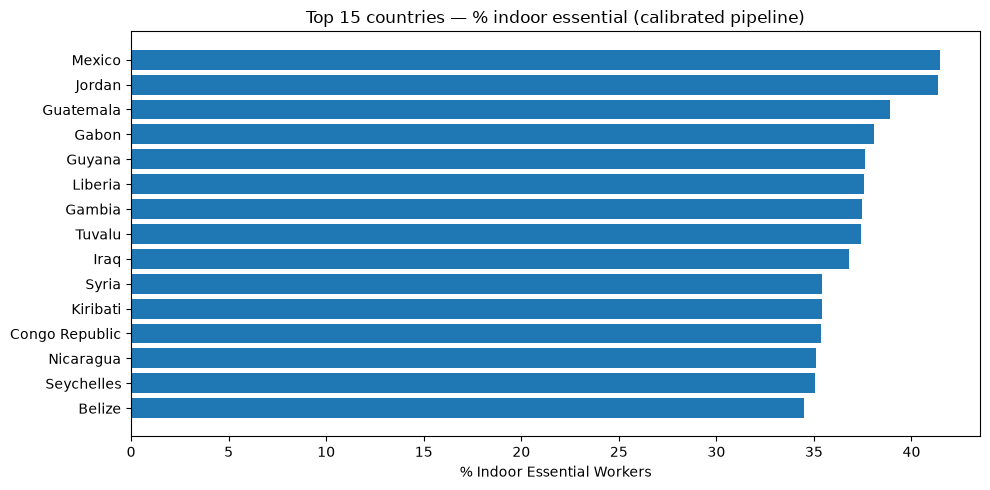

In [16]:
try:
    import matplotlib.pyplot as plt
    top = lf.nlargest(15, '%Indoor Essential Workers')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top['Country Name'], top['%Indoor Essential Workers'] * 100)
    ax.set_xlabel('% Indoor Essential Workers')
    ax.set_title('Top 15 countries — % indoor essential (calibrated pipeline)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed — skip bar chart or pip install matplotlib')


## 9. Write outputs & re-run tests

The quick-start cell already wrote CSVs. To refresh without re-running earlier cells:

```python
ew.run_pipeline(DATA, RESULTS, write=True, write_indoor_sensitivity=True)
```

Tests (from repo root):

```bash
pytest tests/test_essential_workers.py
pytest tests/test_essential_workers.py --full-data  # uses data/ not fixtures
```


In [17]:
# Uncomment to persist again after editing constants in essential_workers.py:
# ew.run_pipeline(DATA, RESULTS, write=True, write_indoor_sensitivity=True)
print('Pipeline outputs expected in:', RESULTS)
for f in sorted(RESULTS.glob('Essential*.csv')) + sorted(RESULTS.glob('*Overlap*.csv')) + sorted(RESULTS.glob('Onsite*.csv')) + sorted(RESULTS.glob('Indoor_Context*.csv')):
    print(' ', f.name, f.stat().st_size if f.exists() else 'missing')


Pipeline outputs expected in: /Users/james/Documents/Github/InRoomAirFilterScaleUp/results/essential_workers
  EssentialWorkersByCountry.csv 77889
  EssentialWorkersByGroup.csv 231972
  EssentialWorkersByGroupComposition_ByCountry.csv 245673
  EssentialWorkersByGroupComposition_ByRegion.csv 35124
  EssentialWorkersByGroupComposition_Global.csv 1643
  EssentialWorkersByRegion.csv 7755
  Essential_Workers_Validation.csv 14608
  Group_Overlap_Calibration.csv 278122
  Onsite_Housing_Worker_Requirements.csv 18988
  Indoor_Context_Sensitivity.csv 2610


## 10. Key results

Numbers for the essential and vital worker results section of the manuscript.
Uses the indoor method from `IndoorContextMethod` in `data/scale_up/settings.csv`.

Run section 1 first, or re-run the pipeline here if `lf` is not in memory.


In [18]:
# Reload pipeline outputs if this section is run on its own
if 'lf' not in globals() or 'outputs' not in globals():
    outputs = ew.run_pipeline(DATA, RESULTS, write=False)
    lf = outputs.labour_force_df

group_df = outputs.group_df
ilo_pct_df = outputs.ilo_pct_df
validation = ew.validate_against_ilo(lf, ilo_pct_df)

global_summary = ew.compute_global_worker_summary(lf)
range_compression = ew.summarize_indoor_range_compression(lf)
_, gdp_correlations = ew.summarize_worker_shares_vs_gdp(lf, group_df)
group_composition = ew.summarize_group_composition(group_df)
rankings = ew.rank_countries_by_worker_pct(lf, n=5)

labour_force = global_summary.attrs['labour_force']


def fmt_pct(value, digits=1):
    """Format a percentage for manuscript text."""
    return f"{value:.{digits}f}%"


def fmt_billion(count):
    """Format a worker count in billions."""
    return f"{count / 1e9:.2f}"

def fmt_million(count):
    """Format a worker count in millions."""
    return f"{count / 1e6:.0f}"

def fmt_p(p_value):
    """Format a p-value for manuscript text."""
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"


def country_pct(code, column):
    """Return one country's share as a percent."""
    row = lf.loc[lf['Country Code'] == code, column]
    return float(row.iloc[0] * 100.0)


def correlation_row(column):
    """Look up one GDP correlation row."""
    match = gdp_correlations.loc[gdp_correlations['column'] == column].iloc[0]
    return float(match['Spearman ρ']), float(match['Spearman p'])


def sector_table(column):
    """Occupational-group shares sorted largest first."""
    table = group_composition[['occupational_group', column]].copy()
    table[column] = 100.0 * table[column]
    return table.sort_values(column, ascending=False)

print('=' * 72)
print('ESSENTIAL AND VITAL WORKERS')
print(f"IndoorContextMethod: {ew.load_indoor_context_method()}")
print('=' * 72)

essential_pct = global_summary.loc['Essential workers', '% of Labour Force']
essential_workers = global_summary.loc['Essential workers', 'Workers']
vital_pct = global_summary.loc['Vital workers', '% of Labour Force']
vital_workers = global_summary.loc['Vital workers', 'Workers']
indoor_essential_pct = global_summary.loc['Indoor essential workers', '% of Labour Force']
indoor_essential_workers = global_summary.loc['Indoor essential workers', 'Workers']
indoor_vital_pct = global_summary.loc['Indoor vital workers', '% of Labour Force']
indoor_vital_workers = global_summary.loc['Indoor vital workers', 'Workers']

print(
    f"\nEssential workers make up {fmt_pct(essential_pct)} of the labour force "
    f"across the globe, totalling {fmt_billion(essential_workers)} billion people "
    f"in {len(lf)} countries and territories."
)
print(
    f"These results match the ILO's finding of {validation.mean_ilo_pct_essential:.0f}% "
    f"of the labour force across {len(validation.merged_df)} countries, with a mean "
    f"country-level difference of {validation.mean_abs_delta_pp:.2f} percentage points."
)

essential_bottom = rankings['% Essential'][1].iloc[0]
essential_top_two = rankings['% Essential'][0].head(2)
max_names = ' and '.join(essential_top_two['Country Name'])
max_range = (
    f"{essential_top_two['% Essential'].iloc[-1]:.1f}"
    f"–{essential_top_two['% Essential'].iloc[0]:.1f}%"
)
print(
    f"\nAt the country level, essential worker percentages vary from "
    f"{essential_bottom['% Essential']:.1f}% in {essential_bottom['Country Name']} "
    f"to {max_range} in countries such as {max_names}."
)

rho_essential, p_essential = correlation_row('%Essential Workers')
rho_vital, p_vital = correlation_row('%Vital Workers')
print(
    f"\nWealthier countries have fewer essential workers relative to their workforce "
    f"({fmt_p(p_essential)}; Spearman rho = {rho_essential:.2f}) and the same holds for "
    f"vital workers ({fmt_p(p_vital)}; Spearman rho = {rho_vital:.2f})."
)

print(
    f"\nOverall, vital workers make up {fmt_pct(vital_pct)} of the world's labour force, "
    f"equal to {fmt_billion(vital_workers)} billion people."
)
print(
    f"Luxembourg decreases from {country_pct('LUX', '%Essential Workers'):.2f}% essential "
    f"to {country_pct('LUX', '%Vital Workers'):.2f}% vital."
)
print(
    f"Mozambique decreases from {country_pct('MOZ', '%Essential Workers'):.1f}% essential "
    f"to {country_pct('MOZ', '%Vital Workers'):.1f}% vital."
)
vital_top = rankings['% Vital'][0].iloc[0]
print(
    f"The largest vital workforce is in {vital_top['Country Name']} "
    f"at {vital_top['% Vital']:.1f}%."
)

print(
    f"\nGlobally, indoor essential workers make up {fmt_pct(indoor_essential_pct)} of the "
    f"labour force ({fmt_billion(indoor_essential_workers)} billion people) and indoor vital "
    f"workers make up {fmt_pct(indoor_vital_pct)} ({fmt_million(indoor_vital_workers)} million)."
)

rho_indoor_essential, p_indoor_essential = correlation_row('%Indoor Essential Workers')
rho_indoor_vital, p_indoor_vital = correlation_row('%Indoor Vital Workers')
print(
    f"Indoor essential shares are still higher in lower-income countries ({fmt_p(p_indoor_essential)}; "
    f"rho = {rho_indoor_essential:.2f}), as are indoor vital shares ({fmt_p(p_indoor_vital)}; "
    f"rho = {rho_indoor_vital:.2f})."
)
print(
    f"Spearman's rho drops from {rho_essential:.2f} to {rho_indoor_essential:.2f} for essential "
    f"workers and from {rho_vital:.2f} to {rho_indoor_vital:.2f} for vital workers."
)

for transition in range_compression.index:
    row = range_compression.loc[transition]
    print(
        f"\n{transition}: p (indoor SD < total) = {row['p (indoor SD < total)']:.2e}; "
        f"p (indoor log-SD < total) = {row['p (indoor log-SD < total)']:.2e}"
    )

print('\nSector composition (global, worker-weighted):')
print('\nEssential workers:')
for _, row in sector_table('% of Essential Workers').iterrows():
    print(f"  {row['occupational_group']}: {row['% of Essential Workers']:.1f}%")
print('\nVital workers:')
for _, row in sector_table('% of Vital Workers').iterrows():
    print(f"  {row['occupational_group']}: {row['% of Vital Workers']:.1f}%")

rho_food_essential, p_food_essential = correlation_row('Food % of Essential Workers')
rho_food_vital, p_food_vital = correlation_row('Food % of Vital Workers')
print(
    f"\nFood is proportionally larger for poorer countries (essential: {fmt_p(p_food_essential)}, "
    f"rho = {rho_food_essential:.2f}; vital: {fmt_p(p_food_vital)}, rho = {rho_food_vital:.2f})."
)

print('\n--- Tables for copy/paste ---')
display(global_summary)
display(range_compression)
display(gdp_correlations)
display(sector_table('% of Essential Workers').rename(columns={'% of Essential Workers': 'share %'}))
display(sector_table('% of Vital Workers').rename(columns={'% of Vital Workers': 'share %'}))


ESSENTIAL AND VITAL WORKERS
IndoorContextMethod: jem_binary

Essential workers make up 53.1% of the labour force across the globe, totalling 1.99 billion people in 217 countries and territories.
These results match the ILO's finding of 52% of the labour force across 89 countries, with a mean country-level difference of 0.90 percentage points.

At the country level, essential worker percentages vary from 19.7% in Luxembourg to 87.0–87.0% in countries such as Madagascar and Dominica.

Wealthier countries have fewer essential workers relative to their workforce (p < 0.001; Spearman rho = -0.78) and the same holds for vital workers (p < 0.001; Spearman rho = -0.74).

Overall, vital workers make up 34.0% of the world's labour force, equal to 1.27 billion people.
Luxembourg decreases from 19.75% essential to 9.13% vital.
Mozambique decreases from 86.9% essential to 74.4% vital.
The largest vital workforce is in Burundi at 78.1%.

Globally, indoor essential workers make up 25.5% of the labour

,Workers,% of Labour Force,Country min %,Country max %
Category,,,,
Essential workers,1.986967e+09,53.075417,19.749035,86.997125
Indoor essential workers,9.542069e+08,25.488560,6.185498,41.439792
Outdoor essential workers,1.032760e+09,27.586857,2.777074,77.281461
Vital workers,1.271357e+09,33.960194,9.131758,78.100122
Indoor vital workers,3.782665e+08,10.104171,1.974342,21.677205
Outdoor vital workers,8.930901e+08,23.856023,1.102684,76.125780


,n countries,Total country min %,Total country max %,Total range (pp),Total SD (pp),Total mean %,Total CV,Indoor country min %,Indoor country max %,Indoor range (pp),Indoor SD (pp),Indoor mean %,Indoor CV,Δ range (pp),% change in range,Variance ratio (indoor/total),CV ratio (indoor/total),Pitman–Morgan p (two-sided),p (indoor SD < total),p (indoor log-SD < total)
Transition,,,,,,,,,,,,,,,,,,,,
Essential → Indoor essential,217,19.749035,86.997125,67.248090,15.816160,49.424905,0.320004,6.185498,41.439792,35.254295,5.504782,26.354593,0.208874,-31.993796,-47.575769,0.121137,0.652722,2.869955e-47,1.434978e-47,5.609969e-06
Vital → Indoor vital,217,9.131758,78.100122,68.968363,15.696776,29.986414,0.523463,1.974342,21.677205,19.702863,2.841351,10.569852,0.268817,-49.265501,-71.432028,0.032766,0.513535,4.064973e-111,2.032486e-111,3.538260e-14


,Share,column,n,Spearman ρ,Spearman p,Pearson r (log GDP),Pearson p (log GDP)
0,%Essential Workers (% of labour force),%Essential Workers,199.0,-0.784589,9.151217e-43,-0.730427,1.855298e-34
1,%Indoor Essential Workers (% of labour force),%Indoor Essential Workers,199.0,0.033342,6.401308e-01,0.124971,7.862330e-02
2,%Vital Workers (% of labour force),%Vital Workers,199.0,-0.741552,5.410188e-36,-0.651740,1.913840e-25
3,%Indoor Vital Workers (% of labour force),%Indoor Vital Workers,199.0,0.375384,4.676203e-08,0.416126,9.795597e-10
4,Food % of Essential Workers,Food % of Essential Workers,144.0,-0.791142,4.042292e-32,-0.790143,5.459134e-32
5,Food % of Indoor Essential Workers,Food % of Indoor Essential Workers,144.0,-0.117282,1.615281e-01,-0.229989,5.552664e-03
6,Food % of Vital Workers,Food % of Vital Workers,144.0,-0.832308,3.285525e-38,-0.823056,1.050301e-36
7,Food % of Indoor Vital Workers,Food % of Indoor Vital Workers,144.0,-0.519382,2.558025e-11,-0.498319,2.075453e-10


,occupational_group,share %
0,Food,45.876494
2,Retail,17.184700
5,Manual,12.786856
4,Transport,7.572913
1,Health,5.981753
6,Cleaning,3.945466
7,Tech,3.930199
3,Security,2.344782
8,ArmedForces,0.376837


,occupational_group,share %
0,Food,68.993283
4,Transport,9.546907
5,Manual,9.276159
1,Health,5.141003
3,Security,2.890296
2,Retail,1.950121
7,Tech,1.447619
6,Cleaning,0.522357
8,ArmedForces,0.232254
